In [1]:
from pathlib import Path
import json
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

PROJECT_ROOT = Path.cwd().resolve()

# If the notebook is opened from notebooks/, move to project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "day1"
MODEL_DIR = PROJECT_ROOT / "models" / "day1"
RESULTS_DIR = PROJECT_ROOT / "results" / "day1"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Project root: C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids
Data directory: C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids\data\processed\day1
Model directory: C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids\models\day1


In [2]:
metadata_path = DATA_DIR / "split_metadata.json"
model_path = MODEL_DIR / "random_forest_baseline.joblib"

metadata = json.loads(metadata_path.read_text())
model = joblib.load(model_path)

feature_names = metadata["feature_names"]

print("Model:", type(model).__name__)
print("Number of features:", len(feature_names))
print("Split method:", metadata["split_method"])
print("Train rows:", metadata["split_summary"]["train_rows"])
print("Test rows:", metadata["split_summary"]["test_rows"])

Model: RandomForestClassifier
Number of features: 58
Split method: capture_day
Train rows: 1796986
Test rows: 516824


In [3]:
metadata_path = DATA_DIR / "split_metadata.json"
model_path = MODEL_DIR / "random_forest_baseline.joblib"

metadata = json.loads(metadata_path.read_text())
model = joblib.load(model_path)

feature_names = metadata["feature_names"]

print("Model:", type(model).__name__)
print("Number of features:", len(feature_names))
print("Split method:", metadata["split_method"])
print("Train rows:", metadata["split_summary"]["train_rows"])
print("Test rows:", metadata["split_summary"]["test_rows"])

Model: RandomForestClassifier
Number of features: 58
Split method: capture_day
Train rows: 1796986
Test rows: 516824


In [6]:
test_df = pd.read_parquet(DATA_DIR / "test.parquet")

X_test = test_df[feature_names].copy()
y_test = test_df["label_binary"].astype(int)

print("TEST SHAPE:", test_df.shape)
print("FEATURE SHAPE:", X_test.shape)
print("Binary labels:")
print(y_test.value_counts().sort_index())

print("\nOriginal test classes:")
print(test_df["Label"].value_counts())

TEST SHAPE: (516824, 75)
FEATURE SHAPE: (516824, 58)
Binary labels:
label_binary
0    385417
1    131407
Name: count, dtype: int64

Original test classes:
Label
Benign      385417
DDoS        128014
PortScan      1956
Bot           1437
Name: count, dtype: Int64


In [7]:
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
X_train = train_df[feature_names].copy()

train_medians = X_train.median(numeric_only=True)

X_test = X_test.fillna(train_medians)

print("Remaining test NaNs:", int(X_test.isna().sum().sum()))

Remaining test NaNs: 0


In [8]:
y_proba = model.predict_proba(X_test)[:, 1]

print("Probability statistics:")
print(pd.Series(y_proba).describe())

print("\nProbability quantiles:")
print(
    pd.Series(y_proba).quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

Probability statistics:
count    516824.000000
mean          0.048143
std           0.104148
min           0.000000
25%           0.000000
50%           0.000000
75%           0.010000
max           0.997961
dtype: float64

Probability quantiles:
0.500    0.000000
0.750    0.010000
0.900    0.240000
0.950    0.270000
0.990    0.381648
0.995    0.399939
0.999    0.419939
dtype: float64


In [9]:
prob_df = pd.DataFrame({
    "label_binary": y_test.to_numpy(),
    "probability": y_proba,
    "Label": test_df["Label"].astype(str).to_numpy(),
})

print("Benign probability distribution:")
print(
    prob_df.loc[prob_df["label_binary"] == 0, "probability"].describe(
        percentiles=[0.90, 0.95, 0.99, 0.999]
    )
)

print("\nAttack probability distribution:")
print(
    prob_df.loc[prob_df["label_binary"] == 1, "probability"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Benign probability distribution:
count    385417.000000
mean          0.004876
std           0.028244
min           0.000000
50%           0.000000
90%           0.000426
95%           0.020000
99%           0.110000
99.9%         0.364723
max           0.997751
Name: probability, dtype: float64

Attack probability distribution:
count    131407.000000
mean          0.175047
std           0.136842
min           0.000000
10%           0.003328
25%           0.010003
50%           0.230000
75%           0.270000
90%           0.359939
95%           0.379939
99%           0.409939
max           0.997961
Name: probability, dtype: float64


In [10]:
class_probability_summary = (
    prob_df
    .groupby("Label")["probability"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        max="max",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .sort_values("median", ascending=False)
)

class_probability_summary

,count,mean,median,max,p90,p95,p99
Label,,,,,,,
DDoS,128014,0.177846,0.230000,0.719902,0.359939,0.379939,0.409939
PortScan,1956,0.117940,0.050000,0.997961,0.249934,0.352499,0.997390
Bot,1437,0.003435,0.000005,0.020000,0.010000,0.010000,0.020000
Benign,385417,0.004876,0.000000,0.997751,0.000426,0.020000,0.110000


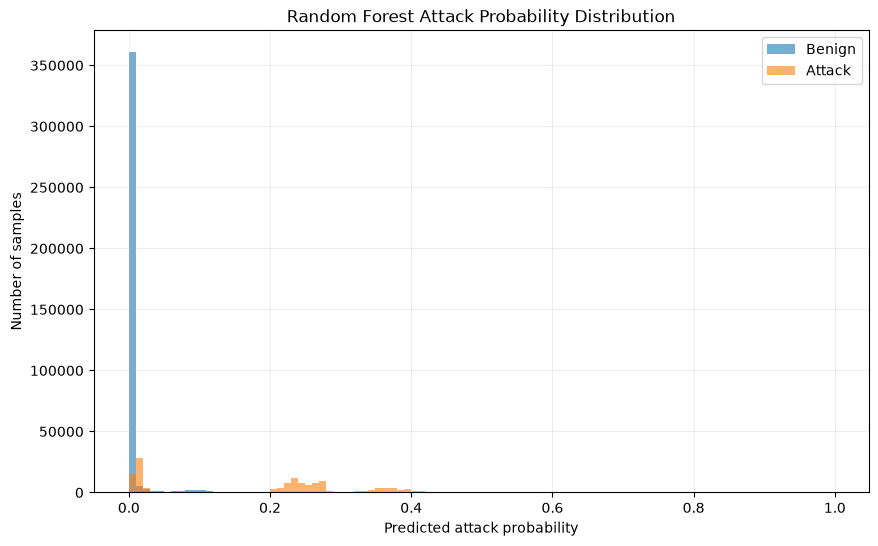

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(
    prob_df.loc[prob_df["label_binary"] == 0, "probability"],
    bins=100,
    alpha=0.6,
    label="Benign",
)

plt.hist(
    prob_df.loc[prob_df["label_binary"] == 1, "probability"],
    bins=100,
    alpha=0.6,
    label="Attack",
)

plt.xlabel("Predicted attack probability")
plt.ylabel("Number of samples")
plt.title("Random Forest Attack Probability Distribution")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [12]:
threshold = 0.50

y_pred_05 = (y_proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_05, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("Threshold:", threshold)
print()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print()

print("Precision:", precision_score(y_test, y_pred_05, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_05, zero_division=0))
print("F1:", f1_score(y_test, y_pred_05, zero_division=0))

Threshold: 0.5

TN: 385182
FP: 235
FN: 131315
TP: 92

Precision: 0.28134556574923547
Recall: 0.0007001149101646031
F1: 0.0013967540650097925


In [13]:
thresholds = np.array([
    0.01,
    0.02,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
])

rows = []

for threshold in thresholds:
    pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1]
    ).ravel()

    rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "predicted_attacks": int(pred.sum()),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
    })

threshold_results = pd.DataFrame(rows)

threshold_results

,threshold,precision,recall,f1,fpr,fnr,predicted_attacks,tp,fp,fn,tn
0,0.01,0.823470,0.881856,0.851663,0.064455,0.118144,140724,115882,24842,15525,360575
1,0.02,0.815819,0.666776,0.733806,0.051324,0.333224,107400,87619,19781,43788,365636
2,0.05,0.852268,0.628939,0.723767,0.037170,0.371061,96973,82647,14326,48760,371091
3,0.10,0.932708,0.626755,0.749719,0.015417,0.373245,88302,82360,5942,49047,379475
4,0.15,0.980560,0.623757,0.762482,0.004216,0.376243,83591,81966,1625,49441,383792
5,0.20,0.988031,0.616276,0.759082,0.002545,0.383724,81964,80983,981,50424,384436
6,0.25,0.986651,0.354357,0.521439,0.001635,0.645643,47195,46565,630,84842,384787
7,0.30,0.978781,0.170600,0.290556,0.001261,0.829400,22904,22418,486,108989,384931
8,0.40,0.810000,0.011095,0.021891,0.000887,0.988905,1800,1458,342,129949,385075
9,0.50,0.281346,0.000700,0.001397,0.000610,0.999300,327,92,235,131315,385182


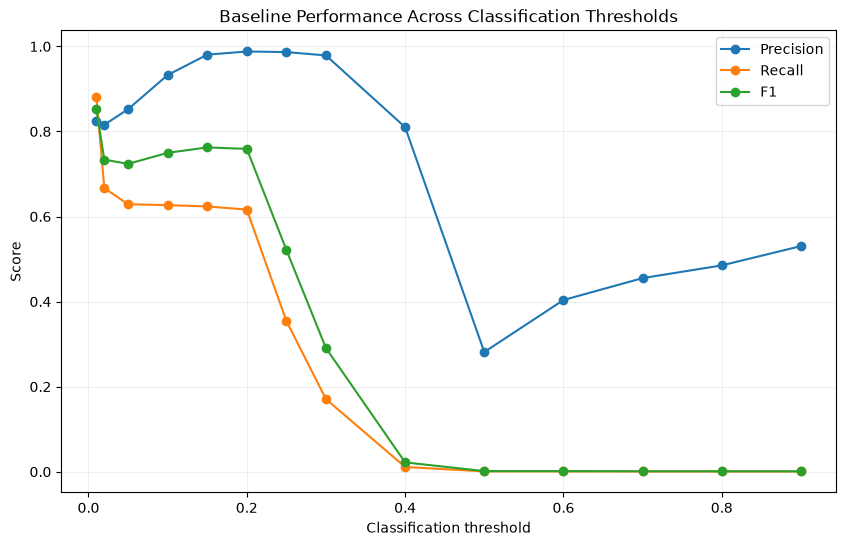

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1",
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Baseline Performance Across Classification Thresholds")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [15]:
best_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best tested threshold by F1:")
print(best_row)

Best tested threshold by F1:
threshold                 0.010000
precision                 0.823470
recall                    0.881856
f1                        0.851663
fpr                       0.064455
fnr                       0.118144
predicted_attacks    140724.000000
tp                   115882.000000
fp                    24842.000000
fn                    15525.000000
tn                   360575.000000
Name: 0, dtype: float64


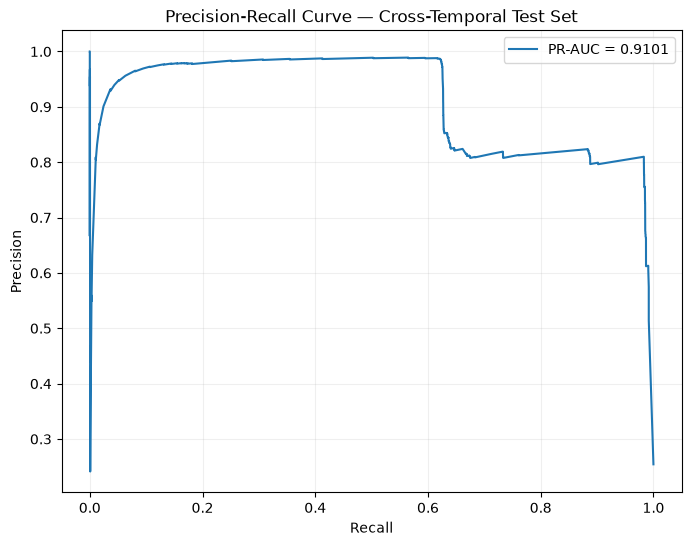

PR-AUC: 0.9100762369019552


In [16]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.4f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Cross-Temporal Test Set")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print("PR-AUC:", pr_auc)

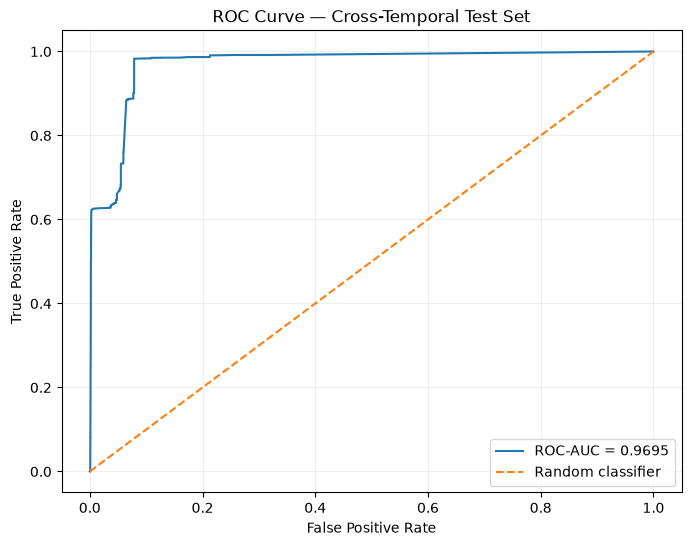

ROC-AUC: 0.9694697874913232


In [17]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cross-Temporal Test Set")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print("ROC-AUC:", roc_auc)

In [18]:
class_results = []

for class_name, group in prob_df.groupby("Label"):
    y_true_class = (group["label_binary"].to_numpy() == 1).astype(int)
    y_pred_class = (group["probability"].to_numpy() >= 0.50).astype(int)

    if class_name == "Benign":
        detected = int(y_pred_class.sum())
        total = len(group)

        class_results.append({
            "class": class_name,
            "samples": total,
            "predicted_attack": detected,
            "detection_rate": np.nan,
            "mean_attack_probability": group["probability"].mean(),
            "median_attack_probability": group["probability"].median(),
            "max_attack_probability": group["probability"].max(),
        })
    else:
        detected = int(y_pred_class.sum())
        total = len(group)

        class_results.append({
            "class": class_name,
            "samples": total,
            "predicted_attack": detected,
            "detection_rate": detected / total if total else np.nan,
            "mean_attack_probability": group["probability"].mean(),
            "median_attack_probability": group["probability"].median(),
            "max_attack_probability": group["probability"].max(),
        })

per_class_results = pd.DataFrame(class_results)

per_class_results.sort_values(
    "mean_attack_probability",
    ascending=False
)

,class,samples,predicted_attack,detection_rate,mean_attack_probability,median_attack_probability,max_attack_probability
2,DDoS,128014,26,0.000203,0.177846,0.230000,0.719902
3,PortScan,1956,66,0.033742,0.117940,0.050000,0.997961
0,Benign,385417,235,NaN,0.004876,0.000000,0.997751
1,Bot,1437,0,0.000000,0.003435,0.000005,0.020000


In [19]:
analysis_path = RESULTS_DIR / "baseline_threshold_analysis.csv"

threshold_results.to_csv(
    analysis_path,
    index=False,
)

class_results_path = RESULTS_DIR / "baseline_per_class_analysis.csv"

per_class_results.to_csv(
    class_results_path,
    index=False,
)

print("Saved:")
print(analysis_path)
print(class_results_path)

Saved:
C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids\results\day1\baseline_threshold_analysis.csv
C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids\results\day1\baseline_per_class_analysis.csv


In [20]:
print("=" * 70)
print("DAY 1 CROSS-TEMPORAL RANDOM FOREST BASELINE")
print("=" * 70)

print(f"Train rows:       {len(train_df):,}")
print(f"Test rows:        {len(test_df):,}")
print(f"Features:         {len(feature_names)}")
print(f"Split method:     {metadata['split_method']}")
print(f"Test classes:     {sorted(test_df['Label'].astype(str).unique())}")
print()
print(f"ROC-AUC:          {roc_auc:.6f}")
print(f"PR-AUC:           {pr_auc:.6f}")
print(f"Precision @ 0.5:  {precision_score(y_test, y_pred_05, zero_division=0):.6f}")
print(f"Recall @ 0.5:     {recall_score(y_test, y_pred_05, zero_division=0):.6f}")
print(f"F1 @ 0.5:         {f1_score(y_test, y_pred_05, zero_division=0):.6f}")
print()
print("Confusion matrix @ 0.5:")
print(cm)
print("=" * 70)

DAY 1 CROSS-TEMPORAL RANDOM FOREST BASELINE
Train rows:       1,796,986
Test rows:        516,824
Features:         58
Split method:     capture_day
Test classes:     ['Benign', 'Bot', 'DDoS', 'PortScan']

ROC-AUC:          0.969470
PR-AUC:           0.910076
Precision @ 0.5:  0.281346
Recall @ 0.5:     0.000700
F1 @ 0.5:         0.001397

Confusion matrix @ 0.5:
[[385182    235]
 [131315     92]]
